# MNIST Classification Using Artificial Neural Network

## Step 1 - Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.feature_selection import VarianceThreshold


## Step 2 - Load MNIST Dataset

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


## Step 3 - Preprocessing

In [4]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0


In [5]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)


## Step 4 - Feature Selection

In [6]:
selector = VarianceThreshold(threshold=0.01)
X_train_fs = selector.fit_transform(X_train_flat)
X_test_fs  = selector.transform(X_test_flat)

print("Original features:", X_train_flat.shape[1])
print("After Feature Selection:", X_train_fs.shape[1])


Original features: 784
After Feature Selection: 444


## Step 5 - Build ANN Model

In [7]:
input_dim = X_train_fs.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


## Step 6 - Compile Mode

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       113,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,106 (578.54 KB)

 Trainable params: 148,106 (578.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7 - Train Model

In [9]:
history = model.fit(
    X_train_fs, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9018 - loss: 0.3310 - val_accuracy: 0.9658 - val_loss: 0.1149
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9589 - loss: 0.1357 - val_accuracy: 0.9727 - val_loss: 0.0917
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9700 - loss: 0.0969 - val_accuracy: 0.9750 - val_loss: 0.0771
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9756 - loss: 0.0775 - val_accuracy: 0.9803 - val_loss: 0.0642
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9798 - loss: 0.0626 - val_accuracy: 0.9795 - val_loss: 0.0618
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9832 - loss: 0.0538 - val_accuracy: 0.9850 - val_loss: 0.0600
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9851 - loss: 0.0458 - val_accuracy: 0.9812 - val_loss: 0.0678
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9863 - loss: 0.0417 - val_accuracy: 0.

## Step 8 - Evaluate on Test Set

In [10]:
test_loss, test_acc = model.evaluate(X_test_fs, y_test)
print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9812 - loss: 0.0661
Test Accuracy: 0.9811999797821045


## Step 9 - Plot Accuracy Curve

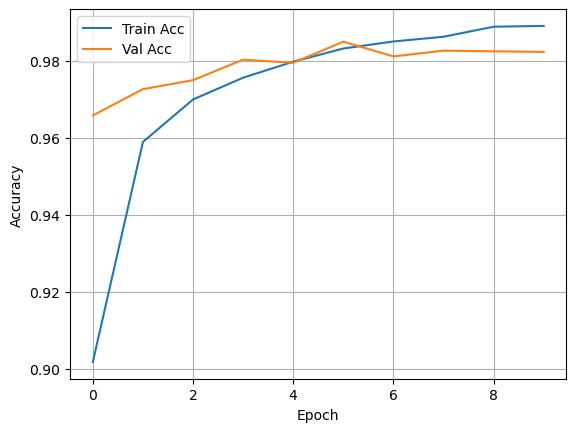

In [11]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()
